<a href="https://colab.research.google.com/github/kashishjagtap02/OIBSIP-Google-Play-Store-EDA-taskno.03/blob/main/Google_Play_Store_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

apps_df = pd.read_csv('/content/apps.csv.zip')
reviews_df = pd.read_csv('/content/user_reviews.csv.zip')


In [ ]:
apps_df.head()


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
reviews_df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [ ]:
apps_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB


In [ ]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [ ]:
print("Apps Dataset Shape:", apps_df.shape)
print("Reviews Dataset Shape:", reviews_df.shape)

Apps Dataset Shape: (9659, 14)
Reviews Dataset Shape: (64295, 5)


In [ ]:
apps_df.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


In [ ]:
reviews_df.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [ ]:
apps_df.duplicated().sum()

np.int64(0)

In [ ]:
apps_df.isnull().sum()

,0
Unnamed: 0,0
App,0
Category,0
Rating,1463
Reviews,0
Size,1227
Installs,0
Type,0
Price,0
Content Rating,0


In [ ]:
apps_df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
apps_df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [ ]:
apps_df['Rating'].median()

4.3

In [ ]:
apps_df['Rating'] = apps_df['Rating'].fillna(apps_df['Rating'].median())

In [ ]:
apps_df['Rating'].isnull().sum()

np.int64(0)

In [ ]:
apps_df['Size'].unique()

array([ 19. ,  14. ,   8.7,  25. ,   2.8,   5.6,  29. ,  33. ,   3.1,
        28. ,  12. ,  20. ,  21. ,  37. ,   2.7,   5.5,  17. ,  39. ,
        31. ,   4.2,   7. ,  23. ,   6. ,   6.1,   4.6,   9.2,   5.2,
        11. ,  24. ,   nan,   9.4,  15. ,  10. ,   1.2,  26. ,   8. ,
         7.9,  56. ,  57. ,  35. ,  54. ,   0.2,   3.6,   5.7,   8.6,
         2.4,  27. ,   2.5,  16. ,   3.4,   8.9,   3.9,   2.9,  38. ,
        32. ,   5.4,  18. ,   1.1,   2.2,   4.5,   9.8,  52. ,   9. ,
         6.7,  30. ,   2.6,   7.1,   3.7,  22. ,   7.4,   6.4,   3.2,
         8.2,   9.9,   4.9,   9.5,   5. ,   5.9,  13. ,  73. ,   6.8,
         3.5,   4. ,   2.3,   7.2,   2.1,  42. ,   7.3,   9.1,  55. ,
         0. ,   6.5,   1.5,   7.5,  51. ,  41. ,  48. ,   8.5,  46. ,
         8.3,   4.3,   4.7,   3.3,  40. ,   7.8,   8.8,   6.6,   5.1,
        61. ,  66. ,   0.1,   8.4,  44. ,   0.7,   1.6,   6.2,  53. ,
         1.4,   3. ,   5.8,   3.8,   9.6,  45. ,  63. ,  49. ,  77. ,
         4.4,   4.8,

In [ ]:
apps_df['Size'].dtype

dtype('float64')

In [ ]:
apps_df['Size'].isnull().sum()

np.int64(1227)

In [ ]:
apps_df['Size'] = apps_df['Size'].fillna(apps_df['Size'].median())

In [ ]:
apps_df['Size'].isnull().sum()

np.int64(0)

In [ ]:
apps_df['Current Ver'].isnull().sum()

np.int64(8)

In [ ]:
apps_df['Current Ver'] = apps_df['Current Ver'].fillna('Unknown')

In [ ]:
apps_df['Current Ver'].isnull().sum()

np.int64(0)

In [ ]:
apps_df['Android Ver'].isnull().sum()

np.int64(2)

In [ ]:
apps_df['Android Ver'].mode()

,Android Ver
0,4.1 and up


In [ ]:
apps_df['Android Ver'] = apps_df['Android Ver'].fillna(apps_df['Android Ver'].mode()[0])

In [ ]:
apps_df['Android Ver'].isnull().sum()

np.int64(0)

In [ ]:
apps_df['Last Updated'].dtype

dtype('O')

In [ ]:
apps_df['Last Updated'] = pd.to_datetime(apps_df['Last Updated'])

In [ ]:
apps_df['Last Updated'].dtype

dtype('<M8[ns]')

In [ ]:
apps_df['Reviews'].dtype

dtype('int64')

In [ ]:
apps_df['Installs'].head()

,Installs
0,"10,000+"
1,"500,000+"
2,"5,000,000+"
3,"50,000,000+"
4,"100,000+"


In [ ]:
apps_df['Price'].head()

,Price
0,0
1,0
2,0
3,0
4,0


In [ ]:
apps_df['Installs'] = apps_df['Installs'].str.replace(',', '')
apps_df['Installs'] = apps_df['Installs'].str.replace('+', '', regex=False)

In [ ]:
apps_df['Installs'] = apps_df['Installs'].astype(int)

In [ ]:
apps_df['Installs'].dtype

dtype('int64')

In [ ]:
apps_df['Installs'].head()

,Installs
0,10000
1,500000
2,5000000
3,50000000
4,100000


In [ ]:
apps_df['Price'].head(10)

,Price
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [ ]:
apps_df['Price'].dtype

dtype('O')

In [ ]:
apps_df['Price'].unique()[:20]

array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99'], dtype=object)

In [ ]:
apps_df['Price'] = apps_df['Price'].str.replace('$', '', regex=False)

In [ ]:
apps_df['Price'] = apps_df['Price'].astype(float)

In [ ]:
apps_df['Price'].dtype

dtype('float64')

In [ ]:
apps_df['Price'].head(10)

,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


In [ ]:
apps_df.describe()

,Rating,Reviews,Size,Installs,Price,Last Updated
count,9659.000000,9.659000e+03,9659.000000,9.659000e+03,9659.000000,9659
mean,4.192442,2.165926e+05,19.328854,7.777507e+06,1.099299,2017-10-30 19:34:02.074748928
min,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,2010-05-21 00:00:00
25%,4.000000,2.500000e+01,5.300000,1.000000e+03,0.000000,2017-08-05 12:00:00
50%,4.300000,9.670000e+02,12.000000,1.000000e+05,0.000000,2018-05-04 00:00:00
75%,4.500000,2.940100e+04,25.000000,1.000000e+06,0.000000,2018-07-17 00:00:00
max,5.000000,7.815831e+07,100.000000,1.000000e+09,400.000000,2018-08-08 00:00:00
std,0.496397,1.831320e+06,20.584647,5.375828e+07,16.852152,NaN


In [ ]:
apps_df[['Category', 'Type', 'Content Rating', 'Genres']].describe()

,Category,Type,Content Rating,Genres
count,9659,9659,9659,9659
unique,33,2,6,118
top,FAMILY,Free,Everyone,Tools
freq,1832,8903,7903,826


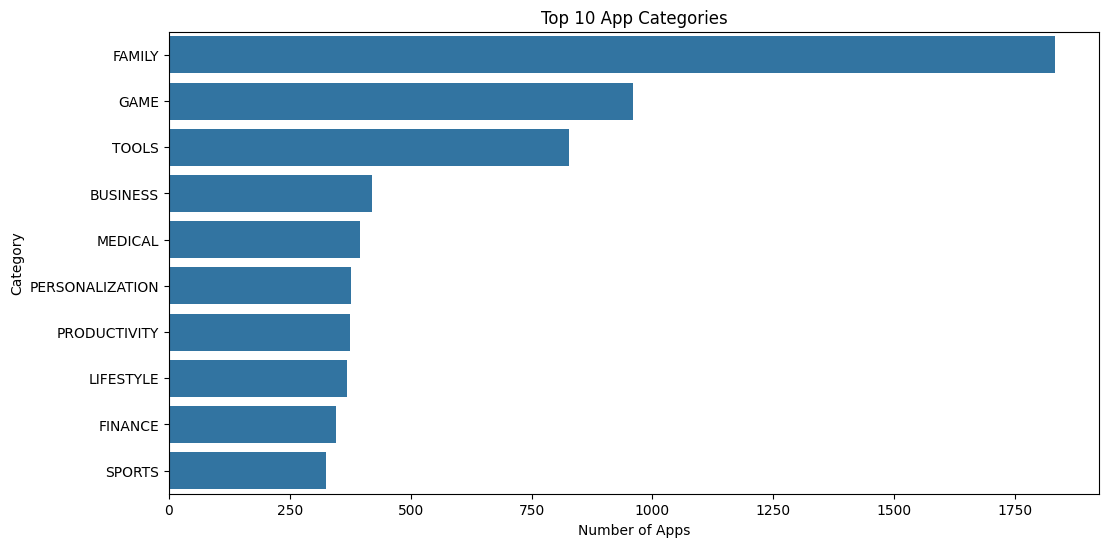

In [ ]:
plt.figure(figsize=(12,6))

category_count = apps_df['Category'].value_counts().head(10)

sns.barplot(
    x=category_count.values,
    y=category_count.index
)

plt.title('Top 10 App Categories')
plt.xlabel('Number of Apps')
plt.ylabel('Category')

plt.show()

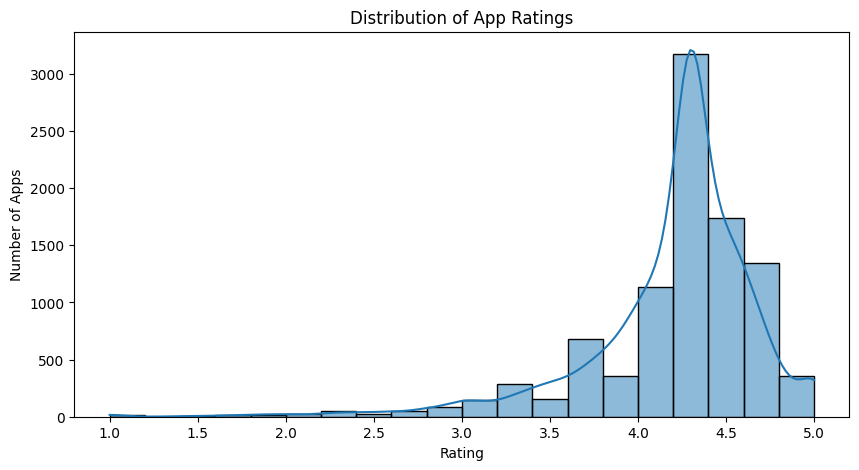

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(apps_df['Rating'], bins=20, kde=True)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.show()

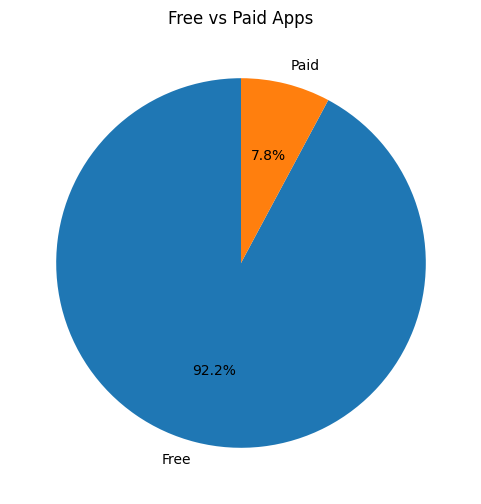

In [ ]:
plt.figure(figsize=(6,6))

apps_df['Type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Free vs Paid Apps')
plt.ylabel('')

plt.show()

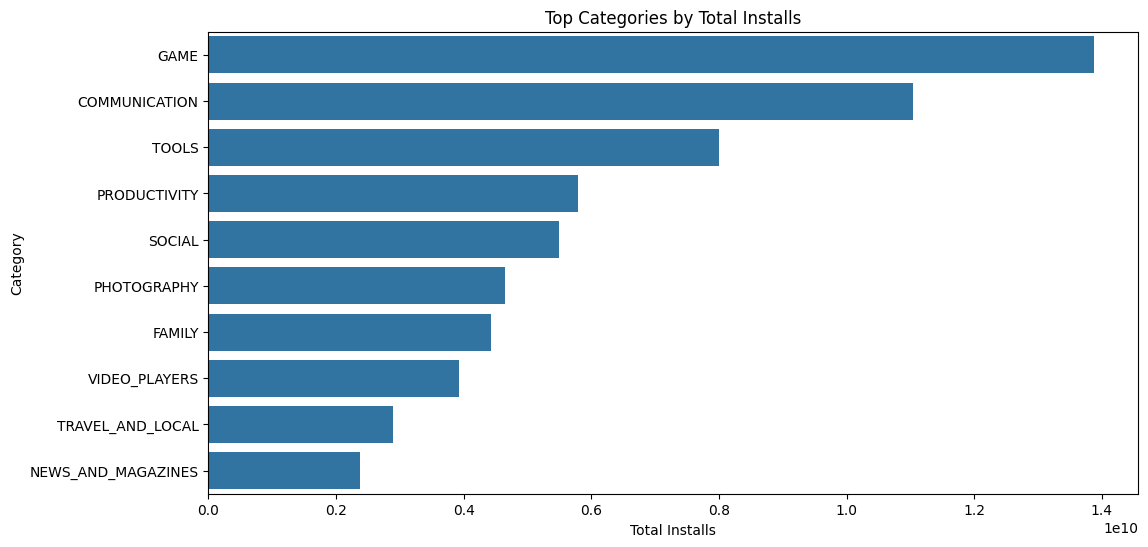

In [ ]:
plt.figure(figsize=(12,6))

top_installs = apps_df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_installs.values, y=top_installs.index)

plt.title('Top Categories by Total Installs')
plt.xlabel('Total Installs')
plt.ylabel('Category')

plt.show()

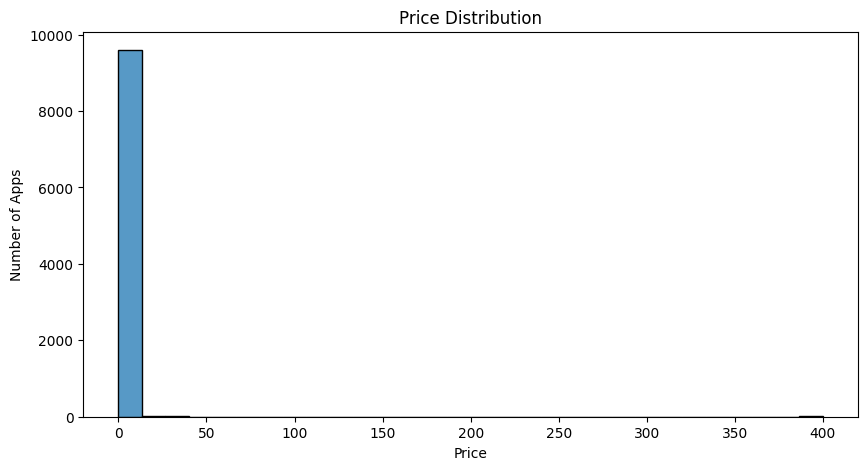

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(apps_df['Price'], bins=30)

plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Number of Apps')

plt.show()

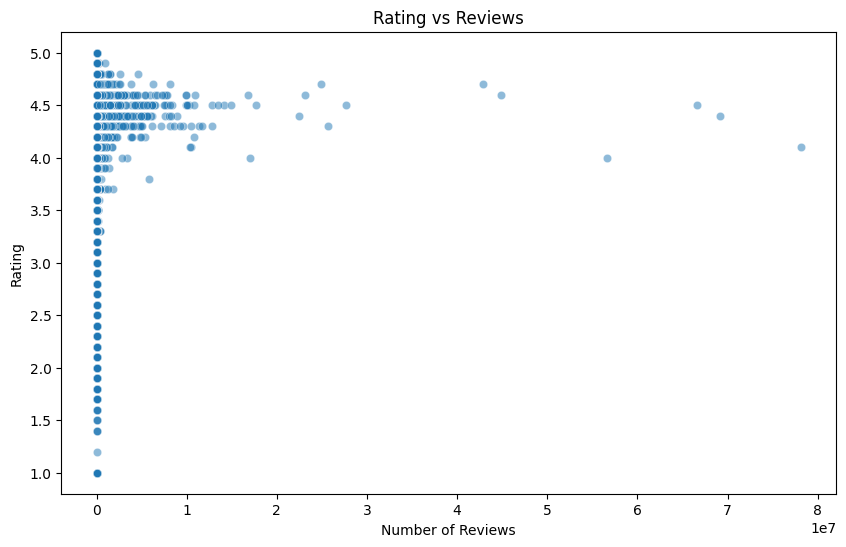

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=apps_df,
    x='Reviews',
    y='Rating',
    alpha=0.5
)

plt.title('Rating vs Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')

plt.show()

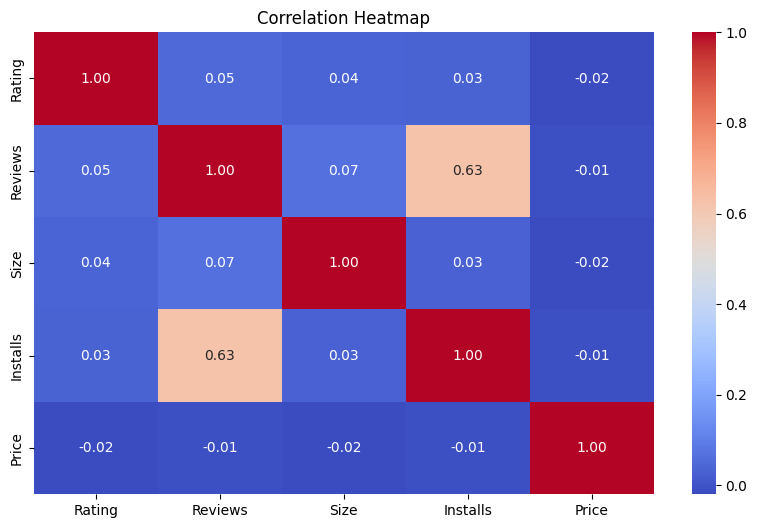

In [ ]:
plt.figure(figsize=(10,6))

numeric_df = apps_df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

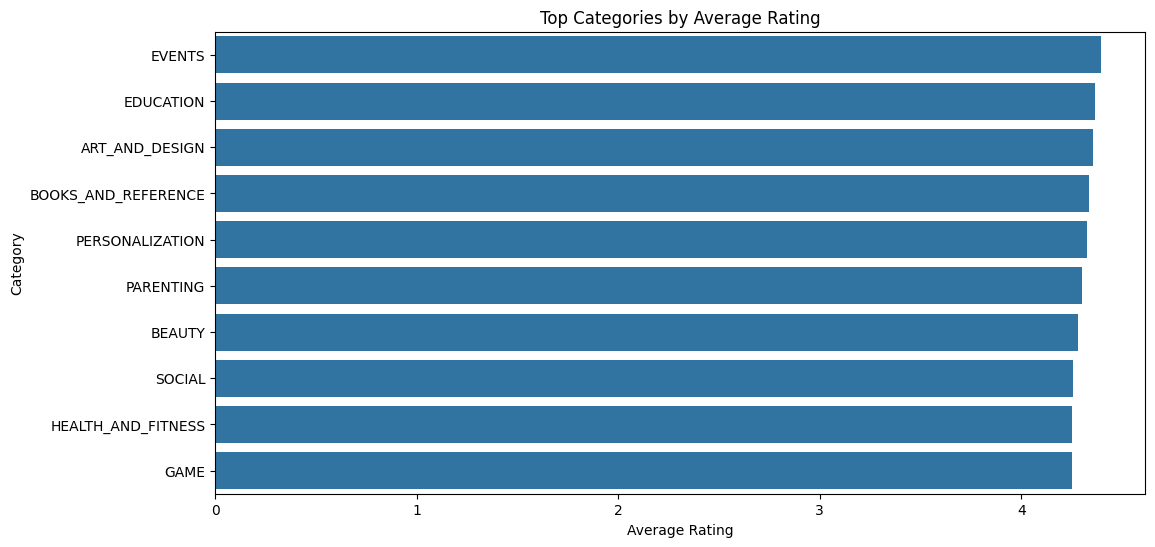

In [ ]:
plt.figure(figsize=(12,6))

avg_rating = apps_df.groupby('Category')['Rating'].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=avg_rating.values,
    y=avg_rating.index
)

plt.title('Top Categories by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Category')

plt.show()